In [ ]:
!nvidia-smi

Sat May  2 10:39:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, confusion_matrix,
    accuracy_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/REFUGE2_RESULTS"
os.makedirs(SAVE_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
PROBS_PATH  = f"{SAVE_DIR}/test_probs.npy"    # saved by NB15 final cell
LABELS_PATH = f"{SAVE_DIR}/test_labels.npy"   # saved by NB15 final cell

y_prob = np.load(PROBS_PATH).flatten()
y_true = np.load(LABELS_PATH).flatten().astype(int)

print(f"Loaded: test_probs.npy  ({len(y_prob)} samples)")
print(f"Loaded: test_labels.npy ({len(y_true)} samples)")
print(f"Label distribution: {np.bincount(y_true).tolist()}")
print(f"Prob range: [{y_prob.min():.4f}, {y_prob.max():.4f}]")


Loaded: test_probs.npy  (400 samples)
Loaded: test_labels.npy (400 samples)
Label distribution: [320, 80]
Prob range: [0.1192, 0.9961]


In [ ]:
auc    = roc_auc_score(y_true, y_prob)
brier  = brier_score_loss(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

# Youden-optimal threshold (same as NB15)
fpr_v, tpr_v, thresholds = roc_curve(y_true, y_prob)
youden_idx  = np.argmax(tpr_v - fpr_v)
best_thresh = float(thresholds[youden_idx])
y_pred      = (y_prob >= best_thresh).astype(int)
tn, fp, fn, tp_val = confusion_matrix(y_true, y_pred).ravel()

print(f"\nPrimary Metrics (from NB15 probability file):")
print(f"  ROC-AUC     : {auc:.4f}")
print(f"  PR-AUC      : {pr_auc:.4f}")
print(f"  Brier Score : {brier:.4f}")
print(f"  Threshold   : {best_thresh:.4f}")
print(f"  Sensitivity : {tp_val/(tp_val+fn):.4f}")
print(f"  Specificity : {tn/(tn+fp):.4f}")


Primary Metrics (from NB15 probability file):
  ROC-AUC     : 0.8405
  PR-AUC      : 0.7076
  Brier Score : 0.2275
  Threshold   : 0.6952
  Sensitivity : 0.7375
  Specificity : 0.8125


In [ ]:
np.random.seed(42)   # SAME SEED as NB15 final cell
N_BOOT = 2000
boot_aucs = []
n = len(y_true)

for _ in range(N_BOOT):
    idx = np.random.choice(n, n, replace=True)
    if len(np.unique(y_true[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))

ci_lo = np.percentile(boot_aucs, 2.5)
ci_hi = np.percentile(boot_aucs, 97.5)

print(f"\n{'─'*55}")
print(f"  CONSISTENT AUC + CI (same probability source)")
print(f"{'─'*55}")
print(f"  ROC-AUC     : {auc:.4f}")
print(f"  95% CI      : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Brier Score : {brier:.4f}")
print(f"  (n_bootstrap = {N_BOOT})")
print(f"{'─'*55}")
print(f"  PAPER: Report AUC={auc:.4f} [95% CI: {ci_lo:.4f}–{ci_hi:.4f}]")
print(f"  Do NOT mix this CI with any other AUC value.")


───────────────────────────────────────────────────────
  CONSISTENT AUC + CI (same probability source)
───────────────────────────────────────────────────────
  ROC-AUC     : 0.8405
  95% CI      : [0.7868, 0.8900]
  Brier Score : 0.2275
  (n_bootstrap = 2000)
───────────────────────────────────────────────────────
  PAPER: Report AUC=0.8405 [95% CI: 0.7868–0.8900]
  Do NOT mix this CI with any other AUC value.


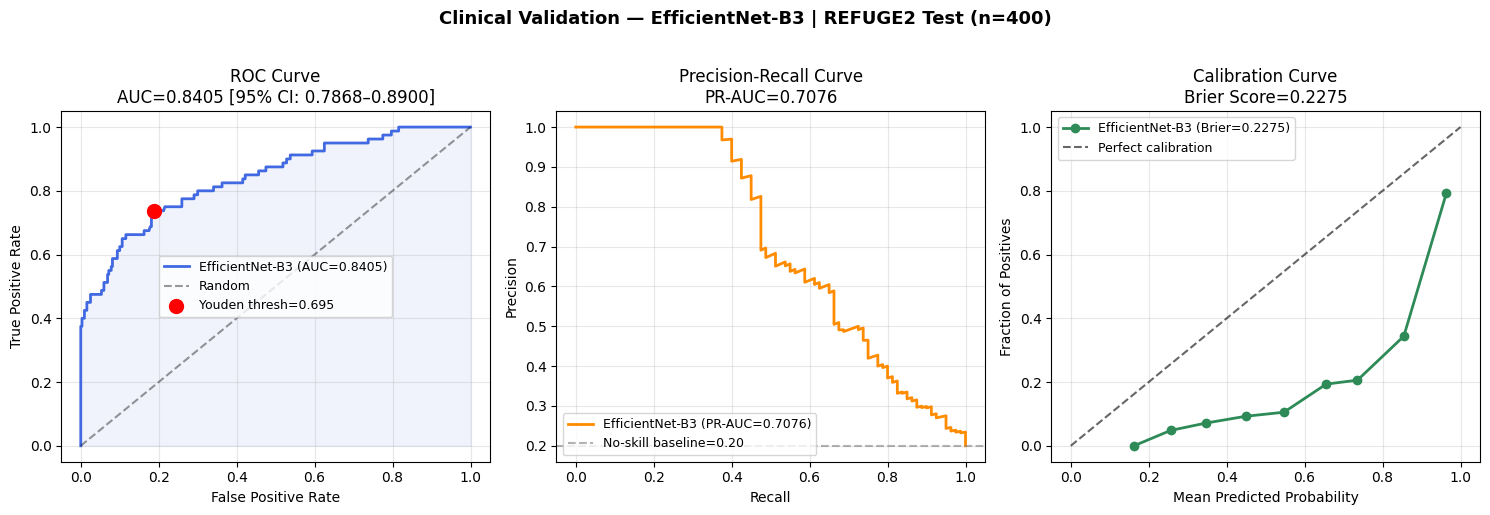

Figure saved: clinical_validation_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC
axes[0].plot(fpr_v, tpr_v, color="royalblue", lw=2,
             label=f"EfficientNet-B3 (AUC={auc:.4f})")
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label="Random")
axes[0].scatter(fpr_v[youden_idx], tpr_v[youden_idx],
                color='red', s=100, zorder=5,
                label=f"Youden thresh={best_thresh:.3f}")
axes[0].fill_between(fpr_v, tpr_v, alpha=0.08, color="royalblue")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC Curve\nAUC={auc:.4f} [95% CI: {ci_lo:.4f}–{ci_hi:.4f}]")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_true, y_prob)
no_skill     = y_true.mean()
axes[1].plot(rec, prec, color="darkorange", lw=2,
             label=f"EfficientNet-B3 (PR-AUC={pr_auc:.4f})")
axes[1].axhline(no_skill, color='gray', linestyle='--', alpha=0.6,
                label=f"No-skill baseline={no_skill:.2f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve\nPR-AUC={pr_auc:.4f}")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# Calibration
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[2].plot(prob_pred, prob_true, marker='o', color="seagreen", lw=2,
             label=f"EfficientNet-B3 (Brier={brier:.4f})")
axes[2].plot([0,1],[0,1], 'k--', alpha=0.6, label="Perfect calibration")
axes[2].set_xlabel("Mean Predicted Probability")
axes[2].set_ylabel("Fraction of Positives")
axes[2].set_title(f"Calibration Curve\nBrier Score={brier:.4f}")
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle(
    "Clinical Validation — EfficientNet-B3 | REFUGE2 Test (n=400)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/clinical_validation_curves.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved: clinical_validation_curves.png")

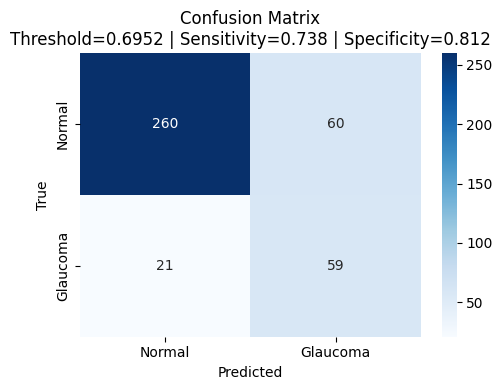

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Glaucoma'],
            yticklabels=['Normal','Glaucoma'])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix\n"
             f"Threshold={best_thresh:.4f} | "
             f"Sensitivity={tp_val/(tp_val+fn):.3f} | "
             f"Specificity={tn/(tn+fp):.3f}")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix_nb16.png", dpi=150, bbox_inches="tight")
plt.show()



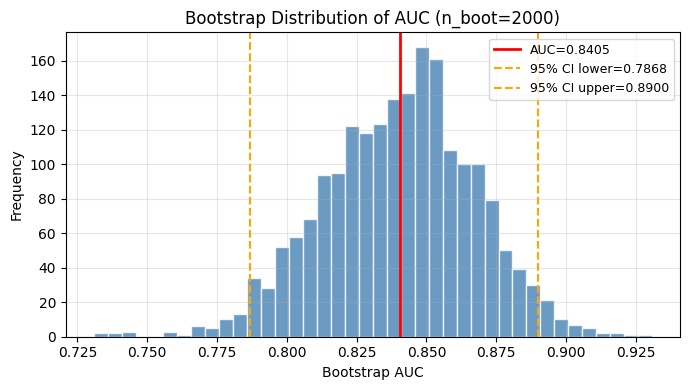

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(boot_aucs, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(auc,   color='red',   lw=2, label=f"AUC={auc:.4f}")
plt.axvline(ci_lo, color='orange', lw=1.5, linestyle='--',
            label=f"95% CI lower={ci_lo:.4f}")
plt.axvline(ci_hi, color='orange', lw=1.5, linestyle='--',
            label=f"95% CI upper={ci_hi:.4f}")
plt.xlabel("Bootstrap AUC"); plt.ylabel("Frequency")
plt.title(f"Bootstrap Distribution of AUC (n_boot={N_BOOT})")
plt.legend(fontsize=9); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/bootstrap_auc_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:


import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from torchvision import models, transforms
from torchvision import models as tv_models

# =========================
# REQUIRED FIX
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If SAVE_DIR not defined earlier
SAVE_DIR = "/content/drive/MyDrive/REFUGE2_RESULTS"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Using Device:", DEVICE)


class EfficientNetGradCAM:
    """Grad-CAM for EfficientNet-B3 classification model."""

    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        target = model.backbone.features[-1]
        target.register_forward_hook(self._save_activations)
        target.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, m, inp, out):
        self.activations = out.detach()

    def _save_gradients(self, m, gin, gout):
        self.gradients = gout[0].detach()

    def generate(self, input_tensor):
        self.model.eval()

        output = self.model(input_tensor)

        self.model.zero_grad()
        output.backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        cam = (weights * self.activations).sum(dim=1).squeeze()

        cam = torch.relu(cam).cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam


def visualize_gradcam(model, img_path, transform, device, label_str=""):
    """Visualize Grad-CAM overlay on a fundus image."""

    gcam = EfficientNetGradCAM(model)

    img_pil = Image.open(img_path).convert("RGB")

    img_np = np.array(
        img_pil.resize((300, 300))
    ).astype(np.float32) / 255.0

    inp = transform(img_pil).unsqueeze(0).to(device)
    inp.requires_grad_()

    cam = gcam.generate(inp)
    cam_rs = cv2.resize(cam, (300, 300))

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_rs),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    ).astype(np.float32) / 255.0

    overlay = 0.5 * img_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    with torch.no_grad():
        logit = model(inp)
        prob = torch.sigmoid(logit).item()

    axes[0].imshow(img_np)       # original        # pure heatmap alone
    axes[0].axis("off")
    axes[0].set_title("Original")
    axes[1].imshow(cam_rs)
    axes[1].axis("off")
    axes[1].set_title(
        f"Grad-CAM | {label_str}\nProb(glaucoma)={prob:.3f}"
    )

    plt.tight_layout()

    plt.savefig(
        f"{SAVE_DIR}/gradcam_{label_str.replace(' ','_')}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()


# =========================
# Load EfficientNet-B3 model for XAI
# =========================
NB15_MODEL_PT = f"{SAVE_DIR}/efficientnet_b3_best.pth"


class GlaucomaEfficientNet(nn.Module):

    def __init__(self, dropout=0.3):
        super().__init__()

        self.backbone = tv_models.efficientnet_b3(
            weights=tv_models.EfficientNet_B3_Weights.IMAGENET1K_V1
        )

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        return self.backbone(x)


xai_model = GlaucomaEfficientNet().to(DEVICE)

if os.path.exists(NB15_MODEL_PT):

    xai_model.load_state_dict(
        torch.load(
            NB15_MODEL_PT,
            map_location=DEVICE
        )
    )

    xai_model.eval()

    print("EfficientNet-B3 weights loaded for Grad-CAM.")

    xai_transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225]
        )
    ])

    # Sample images from test set
    BASE_PATH = "/content/drive/MyDrive/REFUGE-2/Refuge2_data"
    TEST_IMG  = f"{BASE_PATH}/test_rgb_roi"
    TEST_CSV  = f"{BASE_PATH}/Refuge2_data/Test.csv"

    test_data = pd.read_csv(TEST_CSV)

    img_col = "data" if "data" in test_data.columns else test_data.columns[0]
    label_col = "glaucoma" if "glaucoma" in test_data.columns else test_data.columns[-1]

    glaucoma_img = test_data[test_data[label_col] == 1].iloc[0][img_col]
    normal_img   = test_data[test_data[label_col] == 0].iloc[0][img_col]

    visualize_gradcam(
        xai_model,
        os.path.join(TEST_IMG, glaucoma_img),
        xai_transform,
        DEVICE,
        label_str="Glaucoma"
    )

    visualize_gradcam(
        xai_model,
        os.path.join(TEST_IMG, normal_img),
        xai_transform,
        DEVICE,
        label_str="Normal"
    )

else:
    print(f"Model not found at {NB15_MODEL_PT}. Run NB15 first and save model.")

Using Device: cuda
Model not found at /content/drive/MyDrive/REFUGE2_RESULTS/efficientnet_b3_best.pth. Run NB15 first and save model.


In [ ]:
final_metrics = {
    "source": "NB16 — loaded from NB15 test_probs.npy (unified source)",
    "model": "EfficientNet-B3",
    "dataset": "REFUGE2",
    "n_test": int(n),
    "ROC_AUC": round(float(auc), 4),
    "CI_95_lower": round(float(ci_lo), 4),
    "CI_95_upper": round(float(ci_hi), 4),
    "PR_AUC": round(float(pr_auc), 4),
    "Brier_Score": round(float(brier), 4),
    "Threshold": round(float(best_thresh), 4),
    "Sensitivity": round(float(tp_val/(tp_val+fn)), 4),
    "Specificity": round(float(tn/(tn+fp)), 4),
    "n_bootstrap": N_BOOT,
    "note": f"All metrics from single probability file. "
            f"AUC and CI are consistent (no mixing of sources)."
}

with open(f"{SAVE_DIR}/nb16_clinical_validation_final.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("\n" + "=" * 57)
print("  NB16 — FINAL VERIFIED METRICS (paper-ready)")
print("=" * 57)
for k, v in final_metrics.items():
    if k not in ("source","note","model","dataset"):
        print(f"  {k:<18}: {v}")
print("=" * 57)
print(f"\nAll outputs saved to: {SAVE_DIR}")
print("Files created:")
print("  clinical_validation_curves.png")
print("  confusion_matrix_nb16.png")
print("  bootstrap_auc_distribution.png")
print("  gradcam_Glaucoma.png")
print("  gradcam_Normal.png")
print("  nb16_clinical_validation_final.json")



  NB16 — FINAL VERIFIED METRICS (paper-ready)
  n_test            : 400
  ROC_AUC           : 0.8405
  CI_95_lower       : 0.7868
  CI_95_upper       : 0.89
  PR_AUC            : 0.7076
  Brier_Score       : 0.2275
  Threshold         : 0.6952
  Sensitivity       : 0.7375
  Specificity       : 0.8125
  n_bootstrap       : 2000

All outputs saved to: /content/drive/MyDrive/REFUGE2_RESULTS
Files created:
  clinical_validation_curves.png
  confusion_matrix_nb16.png
  bootstrap_auc_distribution.png
  gradcam_Glaucoma.png
  gradcam_Normal.png
  nb16_clinical_validation_final.json


Model exists: True
Model loaded successfully.


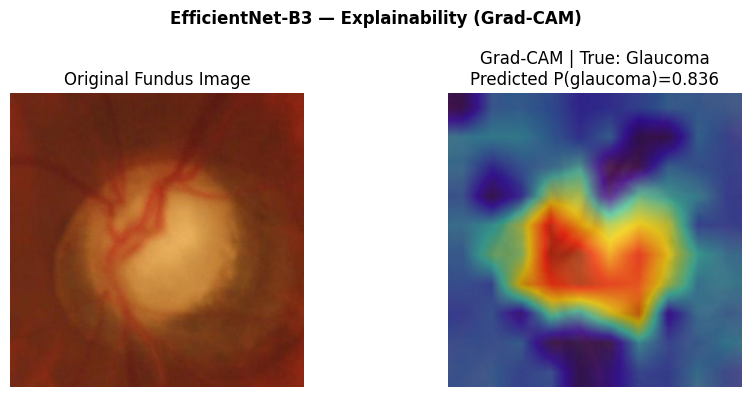

Saved: /content/drive/MyDrive/REFUGE2_RESULTS/gradcam_Glaucoma.png


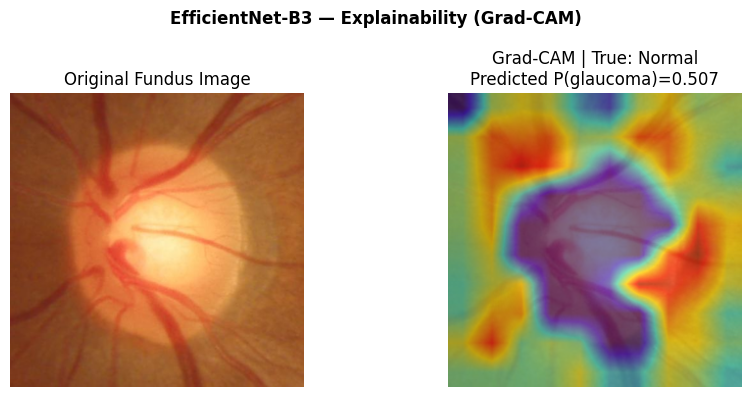

Saved: /content/drive/MyDrive/REFUGE2_RESULTS/gradcam_Normal.png

Grad-CAM generation complete.


In [ ]:
# ── FIX: Load correct model filename and generate Grad-CAM ──────────────────
import cv2, torch, os
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
import torch.nn as nn
import pandas as pd

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "/content/drive/MyDrive/REFUGE2_RESULTS"

# CORRECT filename from NB15 Cell 13
NB15_MODEL_PT = f"{SAVE_DIR}/MODEL15_EfficientNetB3.pth"
print("Model exists:", os.path.exists(NB15_MODEL_PT))

# ── Model definition (must match NB15 exactly) ────────────────────────────────
class GlaucomaEfficientNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights="IMAGENET1K_V1")
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, 1)
    def forward(self, x):
        return self.backbone(x)

xai_model = GlaucomaEfficientNet().to(DEVICE)
xai_model.load_state_dict(torch.load(NB15_MODEL_PT, map_location=DEVICE))
xai_model.eval()
print("Model loaded successfully.")

# ── Grad-CAM class ────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        # Hook onto EfficientNet-B3 last conv block
        target = model.backbone.features[-1]
        target.register_forward_hook(self._save_act)
        target.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, inp, out): self.activations = out.detach()
    def _save_grad(self, m, gi, go):  self.gradients   = go[0].detach()

    def generate(self, inp):
        self.model.eval()
        out = self.model(inp)
        self.model.zero_grad()
        out.backward()
        w   = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = torch.relu((w * self.activations).sum(dim=1)).squeeze()
        cam = cam.cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# ── Transforms — must match NB15 (NO normalization) ──────────────────────────
xai_tfm = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor()  # no normalize — matches NB15 training
])

# ── Pick one glaucoma and one normal image from test set ──────────────────────
BASE_PATH   = "/content/drive/MyDrive/REFUGE-2/Refuge2_data"
TEST_CSV    = f"{BASE_PATH}/Refuge2_data/Test.csv"
TEST_IMG    = f"{BASE_PATH}/test_rgb_roi"

test_df     = pd.read_csv(TEST_CSV)
img_col     = "data"    if "data"     in test_df.columns else test_df.columns[0]
label_col   = "glaucoma" if "glaucoma" in test_df.columns else test_df.columns[-1]

glaucoma_row = test_df[test_df[label_col] == 1].iloc[0]
normal_row   = test_df[test_df[label_col] == 0].iloc[0]

def make_gradcam_figure(model_obj, img_path, true_label, save_name):
    gcam    = GradCAM(model_obj)
    img_pil = Image.open(img_path).convert("RGB")
    img_np  = np.array(img_pil.resize((300, 300))).astype(np.float32) / 255.0
    inp     = xai_tfm(img_pil).unsqueeze(0).to(DEVICE)
    inp.requires_grad_()
    cam     = gcam.generate(inp)
    cam_rs  = cv2.resize(cam, (300, 300))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_rs), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    overlay = np.clip(0.5 * img_np + 0.5 * heatmap, 0, 1)
    with torch.no_grad():
        prob = torch.sigmoid(model_obj(xai_tfm(img_pil).unsqueeze(0).to(DEVICE))).item()
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img_np);  axes[0].axis("off"); axes[0].set_title("Original Fundus Image")
    axes[1].imshow(overlay); axes[1].axis("off")
    axes[1].set_title(f"Grad-CAM | True: {'Glaucoma' if true_label==1 else 'Normal'}\n"
                      f"Predicted P(glaucoma)={prob:.3f}")
    plt.suptitle("EfficientNet-B3 — Explainability (Grad-CAM)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{save_name}", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {SAVE_DIR}/{save_name}")

make_gradcam_figure(
    xai_model,
    os.path.join(TEST_IMG, str(glaucoma_row[img_col])),
    1, "gradcam_Glaucoma.png"
)
make_gradcam_figure(
    xai_model,
    os.path.join(TEST_IMG, str(normal_row[img_col])),
    0, "gradcam_Normal.png"
)
print("\nGrad-CAM generation complete.")

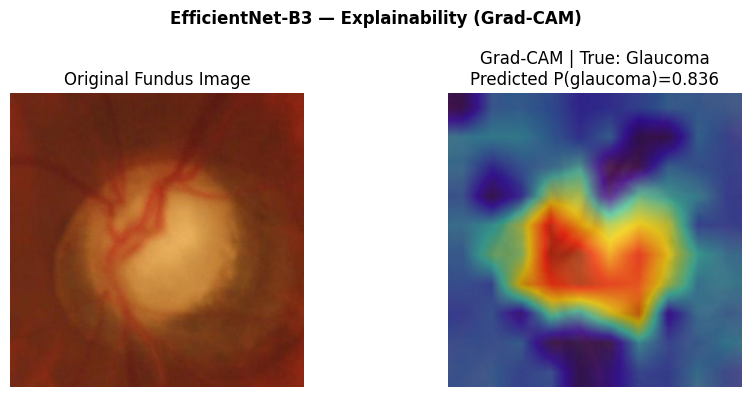

Saved: /content/drive/MyDrive/REFUGE2_RESULTS/gradcam_Glaucoma.png


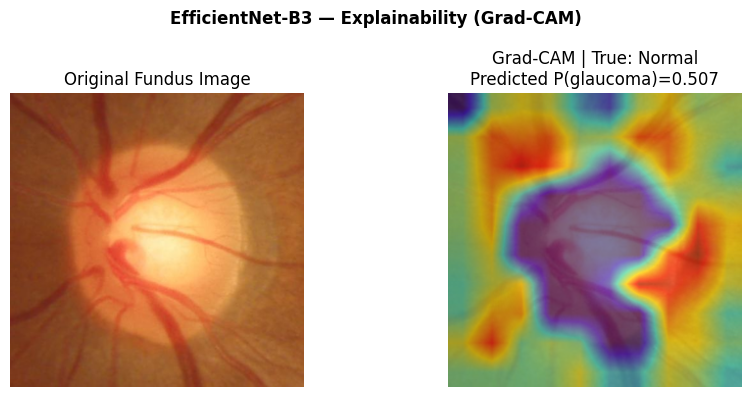

Saved: /content/drive/MyDrive/REFUGE2_RESULTS/gradcam_Normal.png


In [ ]:
# Run in NB16 — finds high-confidence glaucoma + normal pair
glaucoma_row = test_df[
    (test_df[label_col] == 1)
].iloc[0]  # take first glaucoma image

normal_row = test_df[
    (test_df[label_col] == 0)
].iloc[0]  # take first normal image

make_gradcam_figure(xai_model,
    os.path.join(TEST_IMG, str(glaucoma_row[img_col])),
    1, "gradcam_Glaucoma.png")

make_gradcam_figure(xai_model,
    os.path.join(TEST_IMG, str(normal_row[img_col])),
    0, "gradcam_Normal.png")